Calculating Position 1 (USDC Debt)...
Calculating Position 2 (ETH Debt)...
LEVERAGED LP POSITION ANALYSIS SUMMARY

Initial Parameters:
  Capital: $10,000.00
  Leverage: 5.0x
  ETH Price: $5,000.00
  LP Range: $4,900.00 - $5,100.00
  Borrow APR: 10.0%

--------------------------------------------------------------------------------
POSITION 1: USDC DEBT (Long ETH Bias)
--------------------------------------------------------------------------------
  Borrowed USDC: $40,000.00
  Total Position: $50,000.00
  Initial ETH: 5.0240 ETH
  Initial USDC: $24,880.02

  Outcomes at Range Boundaries:
    At Lower Bound ($4900): PnL = $-1,455.93 (-14.6%)
    At Upper Bound ($5100): PnL = $-487.55 (-4.9%)
  Maximum Gain: $-487.55
  Maximum Loss: $-3,894.69

--------------------------------------------------------------------------------
POSITION 2: ETH DEBT (Short ETH Bias)
--------------------------------------------------------------------------------
  Borrowed ETH: 8.0000 ETH ($40,000.00)
  Total

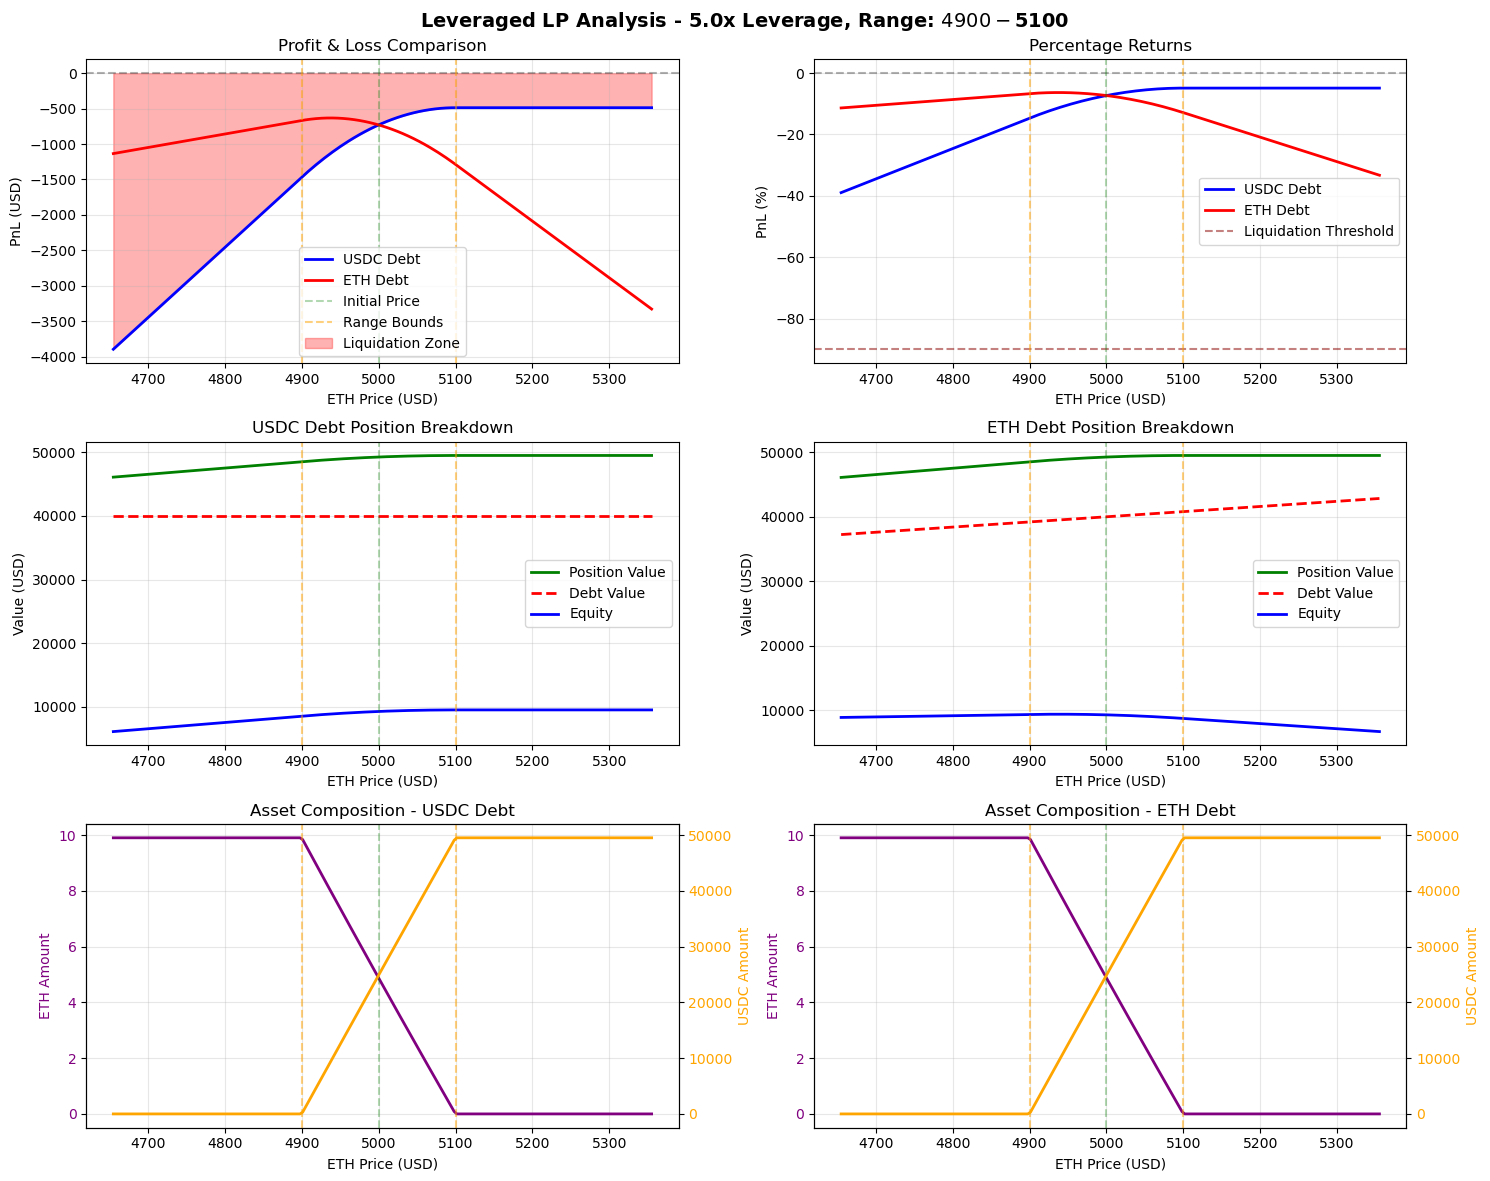


DETAILED PRICE POINT ANALYSIS

  ETH Price USDC Debt PnL USDC Debt % ETH Debt PnL ETH Debt % USDC Liq Risk ETH Liq Risk
      4850       $-1,978      -19.8%        $-766      -7.7%            NO           NO
      4900       $-1,456      -14.6%        $-666      -6.7%            NO           NO
      4950       $-1,033      -10.3%        $-637      -6.4%            NO           NO
      5000         $-732       -7.3%        $-729      -7.3%            NO           NO
      5050         $-550       -5.5%        $-942      -9.4%            NO           NO
      5100         $-488       -4.9%      $-1,301     -13.0%            NO           NO
      5150         $-488       -4.9%      $-1,695     -17.0%            NO           NO


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List
import pandas as pd

@dataclass
class LPPosition:
    """Data class to store LP position parameters and results"""
    capital_usd: float
    eth_price_initial: float
    range_lower: float
    range_upper: float
    leverage: float
    borrow_apr: float
    lp_apr: float  # Expected LP fee APR
    debt_asset: str  # 'USDC' or 'ETH'
    
class LeveragedLPCalculator:
    """
    Calculator for high-leverage concentrated liquidity positions in ETH/USDC pools.
    Implements accurate Uniswap V3 concentrated liquidity math.
    """
    
    def __init__(self):
        self.results = {}
        
    def calculate_liquidity_amounts(self, 
                                   total_value: float,
                                   price: float,
                                   price_lower: float,
                                   price_upper: float) -> Tuple[float, float]:
        """
        Calculate optimal ETH and USDC amounts for concentrated liquidity position.
        Uses Uniswap V3 math for concentrated liquidity.
        """
        sqrt_price = np.sqrt(price)
        sqrt_lower = np.sqrt(price_lower)
        sqrt_upper = np.sqrt(price_upper)
        
        # Calculate liquidity value L
        # When price is in range, we need both assets
        if price_lower <= price <= price_upper:
            # Calculate the ratio of assets needed
            eth_value_ratio = (sqrt_price - sqrt_lower) / (1/sqrt_lower - 1/sqrt_upper) / price
            usdc_value_ratio = 1 - eth_value_ratio
            
            eth_value = total_value * eth_value_ratio
            usdc_value = total_value * usdc_value_ratio
            
            eth_amount = eth_value / price
            usdc_amount = usdc_value
        else:
            # Price out of range - should not happen at initialization
            eth_amount = 0
            usdc_amount = total_value
            
        return eth_amount, usdc_amount
    
    def calculate_position_value(self,
                                eth_amount: float,
                                usdc_amount: float,
                                price_new: float,
                                price_initial: float,
                                price_lower: float,
                                price_upper: float,
                                initial_eth: float,
                                initial_usdc: float) -> Tuple[float, float, float]:
        """
        Calculate position value at new price using concentrated liquidity math.
        Returns (new_eth_amount, new_usdc_amount, total_value_usd)
        """
        sqrt_price_initial = np.sqrt(price_initial)
        sqrt_price_new = np.sqrt(price_new)
        sqrt_lower = np.sqrt(price_lower)
        sqrt_upper = np.sqrt(price_upper)
        
        # Calculate liquidity L from initial position
        if price_initial >= price_lower and price_initial <= price_upper:
            L = initial_usdc / (sqrt_price_initial - sqrt_lower)
        else:
            L = 0
        
        # Calculate new amounts based on new price
        if price_new < price_lower:
            # All in ETH
            new_eth = L * (1/sqrt_lower - 1/sqrt_upper)
            new_usdc = 0
        elif price_new > price_upper:
            # All in USDC
            new_eth = 0
            new_usdc = L * (sqrt_upper - sqrt_lower)
        else:
            # In range - both assets
            new_eth = L * (1/sqrt_price_new - 1/sqrt_upper)
            new_usdc = L * (sqrt_price_new - sqrt_lower)
        
        total_value_usd = new_eth * price_new + new_usdc
        
        return new_eth, new_usdc, total_value_usd
    
    def simulate_usdc_debt_position(self, position: LPPosition) -> Dict:
        """
        Simulate LP position with USDC debt (borrow USDC, more ETH exposure).
        """
        # Calculate leveraged position size
        borrowed_usdc = position.capital_usd * (position.leverage - 1)
        total_position_value = position.capital_usd * position.leverage
        
        # Calculate initial LP allocation
        initial_eth, initial_usdc = self.calculate_liquidity_amounts(
            total_position_value,
            position.eth_price_initial,
            position.range_lower,
            position.range_upper
        )
        
        # Price points to simulate
        price_points = np.linspace(
            position.range_lower * 0.95,
            position.range_upper * 1.05,
            200
        )
        
        results = {
            'prices': price_points,
            'pnl': [],
            'pnl_percent': [],
            'position_value': [],
            'eth_amount': [],
            'usdc_amount': [],
            'impermanent_loss': [],
            'debt_value': [],
            'equity': [],
            'liquidation': []
        }
        
        for price in price_points:
            # Calculate new position
            new_eth, new_usdc, position_value = self.calculate_position_value(
                initial_eth, initial_usdc,
                price,
                position.eth_price_initial,
                position.range_lower,
                position.range_upper,
                initial_eth,
                initial_usdc
            )
            
            # Account for debt
            debt_value = borrowed_usdc
            equity = position_value - debt_value
            
            # Calculate PnL
            pnl = equity - position.capital_usd
            pnl_percent = (pnl / position.capital_usd) * 100
            
            # Calculate impermanent loss vs holding
            hold_value = initial_eth * price + initial_usdc
            il = (position_value - hold_value) / hold_value * 100
            
            # Check liquidation (if equity < 0 or margin call threshold)
            liquidation = equity <= position.capital_usd * 0.1  # 10% margin threshold
            
            results['pnl'].append(pnl)
            results['pnl_percent'].append(pnl_percent)
            results['position_value'].append(position_value)
            results['eth_amount'].append(new_eth)
            results['usdc_amount'].append(new_usdc)
            results['impermanent_loss'].append(il)
            results['debt_value'].append(debt_value)
            results['equity'].append(equity)
            results['liquidation'].append(liquidation)
        
        # Store key metrics
        results['initial_eth'] = initial_eth
        results['initial_usdc'] = initial_usdc
        results['borrowed_usdc'] = borrowed_usdc
        results['total_position'] = total_position_value
        results['max_loss'] = min(results['pnl'])
        results['max_gain'] = max(results['pnl'])
        
        return results
    
    def simulate_eth_debt_position(self, position: LPPosition) -> Dict:
        """
        Simulate LP position with ETH debt (borrow ETH, more USDC/stable exposure).
        """
        # Calculate leveraged position size
        borrowed_eth_value = position.capital_usd * (position.leverage - 1)
        borrowed_eth = borrowed_eth_value / position.eth_price_initial
        total_position_value = position.capital_usd * position.leverage
        
        # Calculate initial LP allocation
        initial_eth, initial_usdc = self.calculate_liquidity_amounts(
            total_position_value,
            position.eth_price_initial,
            position.range_lower,
            position.range_upper
        )
        
        # Price points to simulate
        price_points = np.linspace(
            position.range_lower * 0.95,
            position.range_upper * 1.05,
            200
        )
        
        results = {
            'prices': price_points,
            'pnl': [],
            'pnl_percent': [],
            'position_value': [],
            'eth_amount': [],
            'usdc_amount': [],
            'impermanent_loss': [],
            'debt_value': [],
            'equity': [],
            'liquidation': []
        }
        
        for price in price_points:
            # Calculate new position
            new_eth, new_usdc, position_value = self.calculate_position_value(
                initial_eth, initial_usdc,
                price,
                position.eth_price_initial,
                position.range_lower,
                position.range_upper,
                initial_eth,
                initial_usdc
            )
            
            # Account for debt (ETH debt value changes with price)
            debt_value = borrowed_eth * price
            equity = position_value - debt_value
            
            # Calculate PnL
            pnl = equity - position.capital_usd
            pnl_percent = (pnl / position.capital_usd) * 100
            
            # Calculate impermanent loss vs holding
            hold_value = initial_eth * price + initial_usdc
            il = (position_value - hold_value) / hold_value * 100
            
            # Check liquidation
            liquidation = equity <= position.capital_usd * 0.1  # 10% margin threshold
            
            results['pnl'].append(pnl)
            results['pnl_percent'].append(pnl_percent)
            results['position_value'].append(position_value)
            results['eth_amount'].append(new_eth)
            results['usdc_amount'].append(new_usdc)
            results['impermanent_loss'].append(il)
            results['debt_value'].append(debt_value)
            results['equity'].append(equity)
            results['liquidation'].append(liquidation)
        
        # Store key metrics
        results['initial_eth'] = initial_eth
        results['initial_usdc'] = initial_usdc
        results['borrowed_eth'] = borrowed_eth
        results['total_position'] = total_position_value
        results['max_loss'] = min(results['pnl'])
        results['max_gain'] = max(results['pnl'])
        
        return results
    
    def plot_results(self, results_usdc: Dict, results_eth: Dict, position: LPPosition):
        """
        Create comprehensive plots comparing both positions.
        """
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        fig.suptitle(f'Leveraged LP Analysis - {position.leverage}x Leverage, Range: ${position.range_lower}-${position.range_upper}', fontsize=14, fontweight='bold')
        
        # Plot 1: PnL Comparison
        ax1 = axes[0, 0]
        ax1.plot(results_usdc['prices'], results_usdc['pnl'], 'b-', label='USDC Debt', linewidth=2)
        ax1.plot(results_eth['prices'], results_eth['pnl'], 'r-', label='ETH Debt', linewidth=2)
        ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax1.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3, label='Initial Price')
        ax1.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5, label='Range Bounds')
        ax1.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax1.fill_between(results_usdc['prices'], 
                         [position.capital_usd * -0.9 if liq else pnl for liq, pnl in zip(results_usdc['liquidation'], results_usdc['pnl'])],
                         alpha=0.3, color='red', label='Liquidation Zone')
        ax1.set_xlabel('ETH Price (USD)')
        ax1.set_ylabel('PnL (USD)')
        ax1.set_title('Profit & Loss Comparison')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot 2: PnL Percentage
        ax2 = axes[0, 1]
        ax2.plot(results_usdc['prices'], results_usdc['pnl_percent'], 'b-', label='USDC Debt', linewidth=2)
        ax2.plot(results_eth['prices'], results_eth['pnl_percent'], 'r-', label='ETH Debt', linewidth=2)
        ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax2.axhline(y=-90, color='darkred', linestyle='--', alpha=0.5, label='Liquidation Threshold')
        ax2.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3)
        ax2.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5)
        ax2.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax2.set_xlabel('ETH Price (USD)')
        ax2.set_ylabel('PnL (%)')
        ax2.set_title('Percentage Returns')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        # Plot 3: Position Value & Debt (USDC Debt)
        ax3 = axes[1, 0]
        ax3.plot(results_usdc['prices'], results_usdc['position_value'], 'g-', label='Position Value', linewidth=2)
        ax3.plot(results_usdc['prices'], results_usdc['debt_value'], 'r--', label='Debt Value', linewidth=2)
        ax3.plot(results_usdc['prices'], results_usdc['equity'], 'b-', label='Equity', linewidth=2)
        ax3.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3)
        ax3.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5)
        ax3.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax3.set_xlabel('ETH Price (USD)')
        ax3.set_ylabel('Value (USD)')
        ax3.set_title('USDC Debt Position Breakdown')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        
        # Plot 4: Position Value & Debt (ETH Debt)
        ax4 = axes[1, 1]
        ax4.plot(results_eth['prices'], results_eth['position_value'], 'g-', label='Position Value', linewidth=2)
        ax4.plot(results_eth['prices'], results_eth['debt_value'], 'r--', label='Debt Value', linewidth=2)
        ax4.plot(results_eth['prices'], results_eth['equity'], 'b-', label='Equity', linewidth=2)
        ax4.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3)
        ax4.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5)
        ax4.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax4.set_xlabel('ETH Price (USD)')
        ax4.set_ylabel('Value (USD)')
        ax4.set_title('ETH Debt Position Breakdown')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
        
        # Plot 5: Asset Composition (USDC Debt)
        ax5 = axes[2, 0]
        ax5_2 = ax5.twinx()
        ax5.plot(results_usdc['prices'], results_usdc['eth_amount'], 'purple', label='ETH Amount', linewidth=2)
        ax5_2.plot(results_usdc['prices'], results_usdc['usdc_amount'], 'orange', label='USDC Amount', linewidth=2)
        ax5.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3)
        ax5.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5)
        ax5.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax5.set_xlabel('ETH Price (USD)')
        ax5.set_ylabel('ETH Amount', color='purple')
        ax5_2.set_ylabel('USDC Amount', color='orange')
        ax5.set_title('Asset Composition - USDC Debt')
        ax5.grid(True, alpha=0.3)
        ax5.tick_params(axis='y', labelcolor='purple')
        ax5_2.tick_params(axis='y', labelcolor='orange')
        
        # Plot 6: Asset Composition (ETH Debt)
        ax6 = axes[2, 1]
        ax6_2 = ax6.twinx()
        ax6.plot(results_eth['prices'], results_eth['eth_amount'], 'purple', label='ETH Amount', linewidth=2)
        ax6_2.plot(results_eth['prices'], results_eth['usdc_amount'], 'orange', label='USDC Amount', linewidth=2)
        ax6.axvline(x=position.eth_price_initial, color='g', linestyle='--', alpha=0.3)
        ax6.axvline(x=position.range_lower, color='orange', linestyle='--', alpha=0.5)
        ax6.axvline(x=position.range_upper, color='orange', linestyle='--', alpha=0.5)
        ax6.set_xlabel('ETH Price (USD)')
        ax6.set_ylabel('ETH Amount', color='purple')
        ax6_2.set_ylabel('USDC Amount', color='orange')
        ax6.set_title('Asset Composition - ETH Debt')
        ax6.grid(True, alpha=0.3)
        ax6.tick_params(axis='y', labelcolor='purple')
        ax6_2.tick_params(axis='y', labelcolor='orange')
        
        plt.tight_layout()
        plt.show()
    
    def print_summary(self, results_usdc: Dict, results_eth: Dict, position: LPPosition):
        """
        Print detailed summary of both positions.
        """
        print("=" * 80)
        print("LEVERAGED LP POSITION ANALYSIS SUMMARY")
        print("=" * 80)
        print(f"\nInitial Parameters:")
        print(f"  Capital: ${position.capital_usd:,.2f}")
        print(f"  Leverage: {position.leverage}x")
        print(f"  ETH Price: ${position.eth_price_initial:,.2f}")
        print(f"  LP Range: ${position.range_lower:,.2f} - ${position.range_upper:,.2f}")
        print(f"  Borrow APR: {position.borrow_apr:.1f}%")
        
        print("\n" + "-" * 80)
        print("POSITION 1: USDC DEBT (Long ETH Bias)")
        print("-" * 80)
        print(f"  Borrowed USDC: ${results_usdc['borrowed_usdc']:,.2f}")
        print(f"  Total Position: ${results_usdc['total_position']:,.2f}")
        print(f"  Initial ETH: {results_usdc['initial_eth']:.4f} ETH")
        print(f"  Initial USDC: ${results_usdc['initial_usdc']:,.2f}")
        print(f"\n  Outcomes at Range Boundaries:")
        
        # Find PnL at boundaries
        lower_idx = np.argmin(np.abs(results_usdc['prices'] - position.range_lower))
        upper_idx = np.argmin(np.abs(results_usdc['prices'] - position.range_upper))
        
        print(f"    At Lower Bound (${position.range_lower}): PnL = ${results_usdc['pnl'][lower_idx]:,.2f} ({results_usdc['pnl_percent'][lower_idx]:.1f}%)")
        print(f"    At Upper Bound (${position.range_upper}): PnL = ${results_usdc['pnl'][upper_idx]:,.2f} ({results_usdc['pnl_percent'][upper_idx]:.1f}%)")
        print(f"  Maximum Gain: ${results_usdc['max_gain']:,.2f}")
        print(f"  Maximum Loss: ${results_usdc['max_loss']:,.2f}")
        
        print("\n" + "-" * 80)
        print("POSITION 2: ETH DEBT (Short ETH Bias)")
        print("-" * 80)
        print(f"  Borrowed ETH: {results_eth['borrowed_eth']:.4f} ETH (${results_eth['borrowed_eth'] * position.eth_price_initial:,.2f})")
        print(f"  Total Position: ${results_eth['total_position']:,.2f}")
        print(f"  Initial ETH: {results_eth['initial_eth']:.4f} ETH")
        print(f"  Initial USDC: ${results_eth['initial_usdc']:,.2f}")
        print(f"\n  Outcomes at Range Boundaries:")
        
        print(f"    At Lower Bound (${position.range_lower}): PnL = ${results_eth['pnl'][lower_idx]:,.2f} ({results_eth['pnl_percent'][lower_idx]:.1f}%)")
        print(f"    At Upper Bound (${position.range_upper}): PnL = ${results_eth['pnl'][upper_idx]:,.2f} ({results_eth['pnl_percent'][upper_idx]:.1f}%)")
        print(f"  Maximum Gain: ${results_eth['max_gain']:,.2f}")
        print(f"  Maximum Loss: ${results_eth['max_loss']:,.2f}")
        
        print("\n" + "=" * 80)
        print("KEY INSIGHTS:")
        print("=" * 80)
        print(f"• USDC Debt Position: Benefits from ETH price increase within range")
        print(f"• ETH Debt Position: Benefits from ETH price decrease within range")
        print(f"• Both positions lose significantly if price exits the range")
        print(f"• Liquidation risk exists if equity drops below ~10% of initial capital")
        print(f"• Daily borrow cost: ${position.capital_usd * (position.leverage - 1) * position.borrow_apr / 365 / 100:.2f}")
        
        # Risk metrics
        usdc_sharpe = np.mean(results_usdc['pnl']) / np.std(results_usdc['pnl']) if np.std(results_usdc['pnl']) > 0 else 0
        eth_sharpe = np.mean(results_eth['pnl']) / np.std(results_eth['pnl']) if np.std(results_eth['pnl']) > 0 else 0
        
        print(f"\n• Risk-Adjusted Returns (Sharpe-like):")
        print(f"    USDC Debt: {usdc_sharpe:.2f}")
        print(f"    ETH Debt: {eth_sharpe:.2f}")
        print("=" * 80)

# Main execution
def main():
    # Initialize calculator
    calc = LeveragedLPCalculator()
    
    # Define position parameters
    position = LPPosition(
        capital_usd=10000,
        eth_price_initial=5000,
        range_lower=4900,
        range_upper=5100,
        leverage=5.0,  # 5x leverage
        borrow_apr=10.0,  # 10% APR for borrowing
        lp_apr=50.0,  # Expected 50% APR from LP fees (not implemented in this basic version)
        debt_asset='MIXED'  # Will simulate both
    )
    
    # Simulate Position 1: USDC Debt
    print("Calculating Position 1 (USDC Debt)...")
    results_usdc = calc.simulate_usdc_debt_position(position)
    
    # Simulate Position 2: ETH Debt
    print("Calculating Position 2 (ETH Debt)...")
    results_eth = calc.simulate_eth_debt_position(position)
    
    # Print summary
    calc.print_summary(results_usdc, results_eth, position)
    
    # Plot results
    print("\nGenerating plots...")
    calc.plot_results(results_usdc, results_eth, position)
    
    # Additional analysis - create DataFrame for specific price points
    print("\n" + "=" * 80)
    print("DETAILED PRICE POINT ANALYSIS")
    print("=" * 80)
    
    key_prices = [4850, 4900, 4950, 5000, 5050, 5100, 5150]
    analysis_data = []
    
    for price in key_prices:
        idx = np.argmin(np.abs(results_usdc['prices'] - price))
        analysis_data.append({
            'ETH Price': price,
            'USDC Debt PnL': f"${results_usdc['pnl'][idx]:,.0f}",
            'USDC Debt %': f"{results_usdc['pnl_percent'][idx]:.1f}%",
            'ETH Debt PnL': f"${results_eth['pnl'][idx]:,.0f}",
            'ETH Debt %': f"{results_eth['pnl_percent'][idx]:.1f}%",
            'USDC Liq Risk': 'YES' if results_usdc['liquidation'][idx] else 'NO',
            'ETH Liq Risk': 'YES' if results_eth['liquidation'][idx] else 'NO'
        })
    
    df = pd.DataFrame(analysis_data)
    print("\n", df.to_string(index=False))
    
    return calc, results_usdc, results_eth, position

if __name__ == "__main__":
    calc, results_usdc, results_eth, position = main()